<a href="https://colab.research.google.com/github/blueberrycrumble/AIFFEL_quest_cr/blob/master/DLthon/DLthon_jellyfish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kaggle

In [ ]:
# 캐글 API 키로 로그인
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# 데이터셋을 다운로드해서 캐시에 저장
kagglehub.dataset_download('anshtanwar/jellyfish-types')

100%|██████████| 25.5M/25.5M [00:00<00:00, 126MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/anshtanwar/jellyfish-types/versions/16'

In [ ]:
from google.colab import drive
import os

# 구글 드라이브 마운트
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 원본 데이터셋 경로와 구글 드라이브 경로
source_path = "/root/.cache/kagglehub/datasets/anshtanwar/jellyfish-types/versions/16"
target_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset"

# 절대 경로 설정
data_path = os.path.join(source_path, "Train_Test_Valid")
!mkdir -p "{target_path}"

# 필요한 폴더만 복사
if os.path.exists(data_path):
    !cp -r "{data_path}" "{target_path}/"
    print(f"Train_Test_Valid 폴더만 복사 완료")
else:
    print(f"{data_path} 폴더가 원본에 존재하지 않습니다.")

# 경로 내 파일 확인
files = os.listdir(data_path)
!ls -la {target_path}
print(files)

Train_Test_Valid 폴더만 복사 완료
total 4
drwx------ 5 root root 4096 Mar 31 16:52 Train_Test_Valid
['test', 'Train', 'valid']




---



In [ ]:
import os
import shutil

# 원본 폴더 경로
train_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train"

# 대상 폴더 경로
all_images_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/all_images"

# 대상 폴더 생성
os.makedirs(all_images_path, exist_ok=True)

# 하위 폴더들을 순회하며 이미지 복사
for subdir in os.listdir(train_path):
    subdir_path = os.path.join(train_path, subdir)
    if os.path.isdir(subdir_path):
        for filename in os.listdir(subdir_path):
            if filename.endswith(('.jpg', '.png', '.jpeg')):
                source_path = os.path.join(subdir_path, filename)
                target_path = os.path.join(all_images_path, filename)
                shutil.copy(source_path, target_path)

print("이미지 합치기 완료")

이미지 합치기 완료


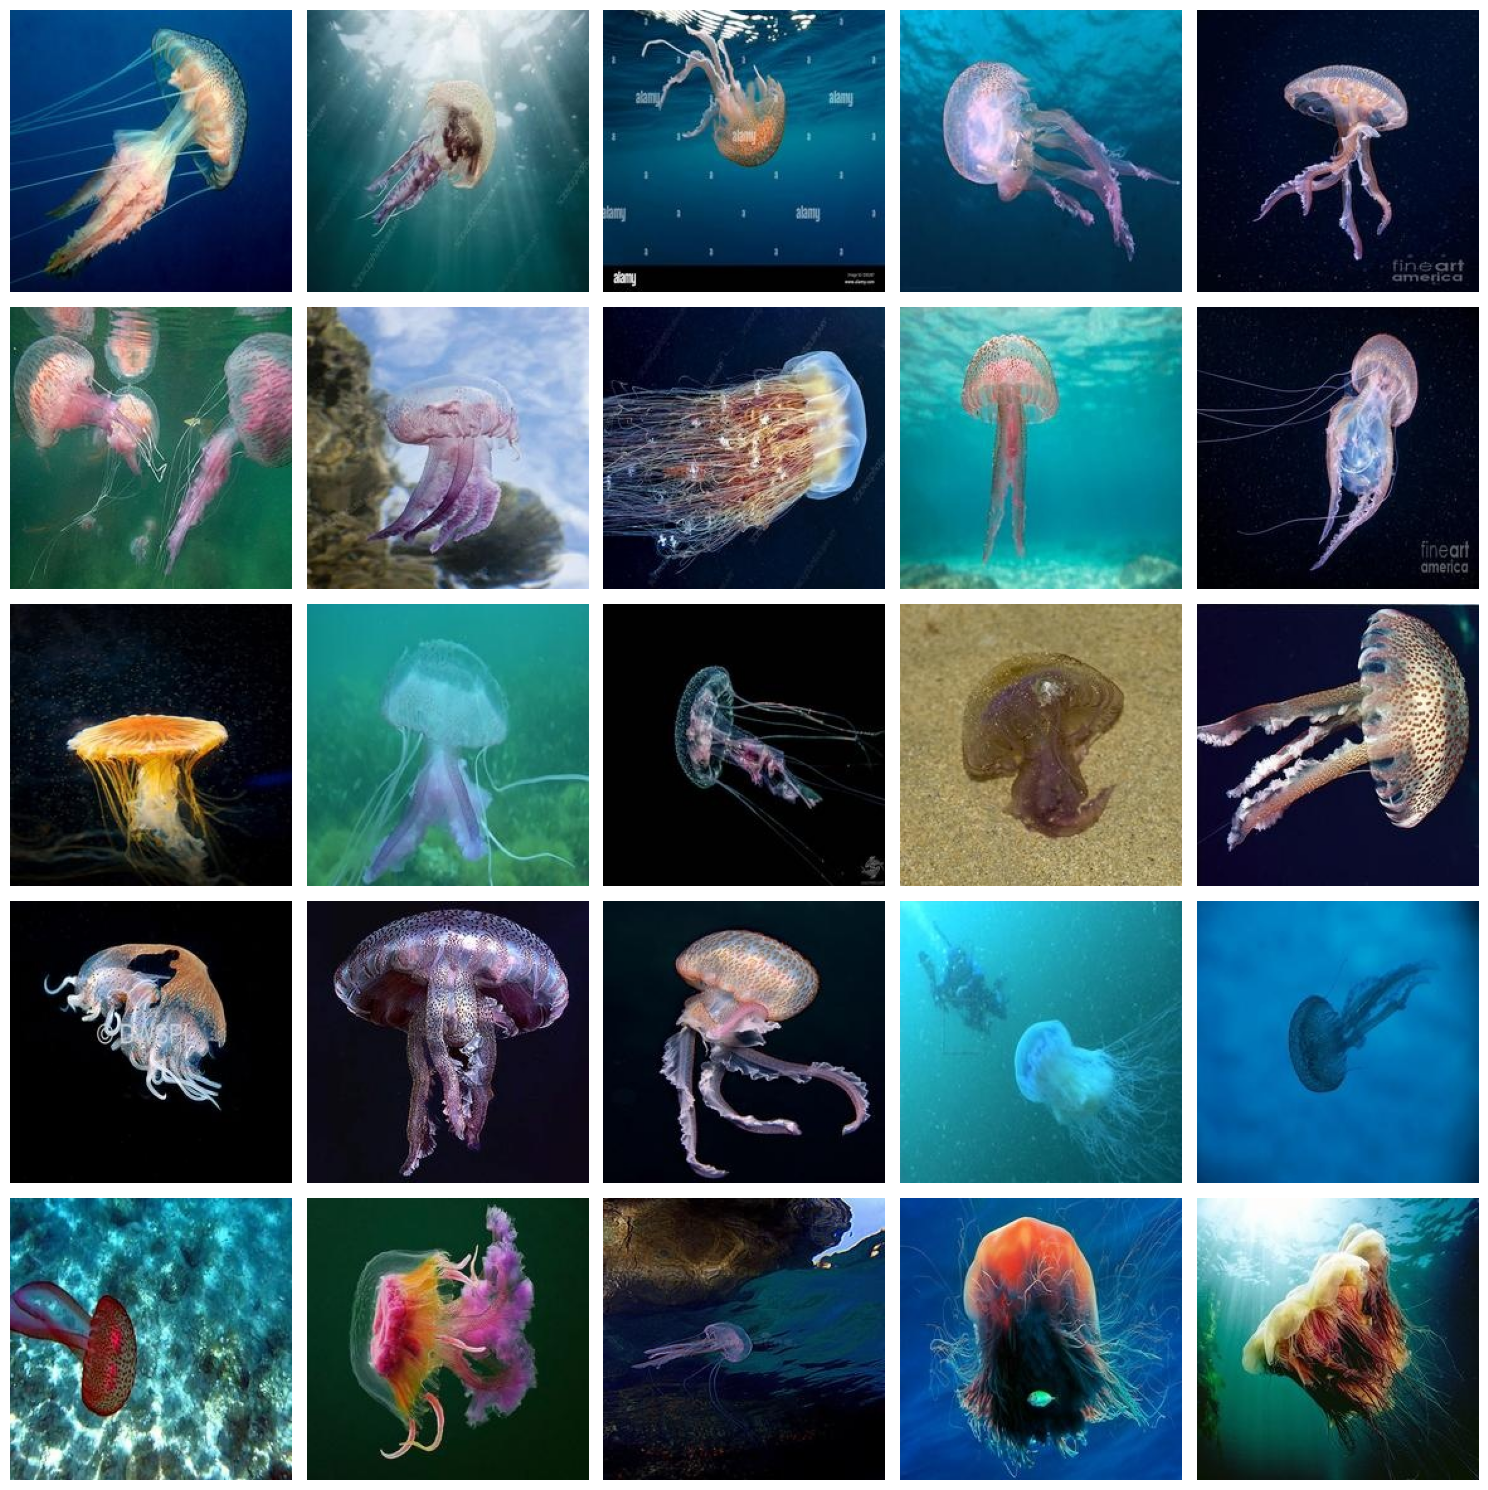

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np

# data_path 경로 설정
data_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/all_images"

# data_path 하위의 모든 이미지 파일 경로 가져오기
image_paths = [os.path.join(data_path, filename) for filename in os.listdir(data_path) if filename.endswith(('.jpg', '.png', '.jpeg'))]

# 그리드 크기 설정 (예: 5x5)
grid_size = (5, 5)

# 이미지 출력
fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(15, 15))  # 그리드 크기와 figure 크기 설정

for i, image_path in enumerate(image_paths):
    if i < grid_size[0] * grid_size[1]:  # 그리드 크기만큼만 이미지 출력
        row = i // grid_size[1]
        col = i % grid_size[1]
        img = mpimg.imread(image_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')  # 축 제거

plt.tight_layout()  # 이미지 간 간격 조정
plt.show()  # 그리드 출력